# `differint` vs `numfracpy` — a detailed hands-on demo

Two small, focused Python libraries for **fractional calculus**:

| | **`differint` 1.0.0** (Matthew Adams) | **`numfracpy` 0.4** |
|---|---|---|
| Core idea | *Array-oriented* differintegrals: give it a function (or samples) and an order, it returns the fractional derivative **at every grid point** | *Point-oriented* operators: give it a function and a single evaluation point `t` (plus step `dt`), it returns one number |
| GL derivative | `GL(α, f, a, b, n)` — FFT convolution, `O(n log n)` | `GLDer1` / `GLDer2(f, t, dt, α)` — direct sum, `O(n)` per point |
| RL derivative | `RL(α, f, a, b, n)` — full coefficient matrix | `RL_der1` / `RL_der2(f, t, dt, α)` |
| Caputo | `CaputoL1point` (0<α<1), `CaputoL2point` (1<α<2) | `Caputo_der1`, `Caputo_der2` (same order ranges) |
| Fractional *integrals* | yes — negative order (`GL(-0.5, …)`, `RL(-0.5, …)`) | `RL_integral(f, a, t, α)` — `scipy.quad` (α > 0 only) |
| Mittag-Leffler | `MittagLeffler(a, b, x)` — power series + closed-form special cases | `Mittag_Leffler_one/two/three` — **Laplace-transform inversion** (Mastroianni-type), plus naive `*_fsum` series |
| FODE solvers | `PCsolver` (predictor-corrector) — ⚠️ broken on numpy ≥ 2 (patched in §7) | `FODE` (Adams P-C), `SystemFODEs` (systems, per-equation orders) |
| Validation | `assert`s with messages | returns **error strings** (no exceptions) |

**What this notebook does**

1. Reproduces the same mathematical object with both libraries and checks them against closed-form answers.
2. Studies convergence in the grid spacing `h` for both.
3. Explores the RL vs Caputo distinction (including the singularity of the RL derivative at the left endpoint).
4. Benchmarks speed and memory characteristics.
5. Solves a fractional ODE and a fractional Lotka–Volterra system.
6. Documents the pitfalls we actually hit (numpy-2.x breakage, grid-snapping, output-length quirks, `GLDer2` evaluating `f` at negative times, …).

Everything below was executed with the venv under `D:\Source\hermes-dir\.venv` (Python 3.11.9, numpy 2.4.6, scipy 1.17.1).


In [1]:
import time
import math
import contextlib
import io
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, special

# --- differint -------------------------------------------------------------
# NOTE: the package's __init__.py declares __all__ but never imports the
# functions, so `import differint; differint.GL` and `from differint import GL`
# both FAIL. The only working import path is the submodule:
import differint
try:
    differint.GL
except AttributeError as e:
    print("differint.GL (top level) ->", type(e).__name__, "-", e)
from differint.differint import (
    GL, RL, GLpoint, RLpoint,
    CaputoL1point, CaputoL2point,
    MittagLeffler, PCsolver,
    GLcoeffs,
)

# --- numfracpy -------------------------------------------------------------
import numfracpy as nfp

print("differint.differint and numfracpy imported OK")
print("numpy", np.__version__, "| scipy", special.gamma(1.5))

differint.GL (top level) -> AttributeError - module 'differint' has no attribute 'GL'
differint.differint and numfracpy imported OK
numpy 2.4.6 | scipy 0.8862269254527579


## 0.1  One-minute sanity check

Both libraries can compute the same number: the Grunwald–Letnikov half-derivative of `f(t)=t²` at `t=1`.
The exact value is `D^{1/2} t²|_{t=1} = Γ(3)/Γ(5/2) = 4/(3√π) ≈ 1.504506`.

Note the different calling conventions: `differint` takes a *domain and a number of points* (the right
endpoint `domain_end` is the evaluation point); `numfracpy` takes an *evaluation point* `t` and a step `dt`
and internally uses `n = int(t/dt)` sub-intervals.


In [2]:
alpha = 0.5
N = 100                       # numfracpy: n = int(t/dt) = 100 sub-intervals
dt = 1.0 / N                  # so that t = 1.0 lands exactly on the grid

# differint: 101 points on [0, 1], evaluated at the right endpoint
v_dif = GLpoint(alpha, lambda t: t**2, 0.0, 1.0, N + 1)
# numfracpy: one pointwise call
v_nfp = nfp.GLDer1(lambda t: t**2, 1.0, dt, alpha)
v_exact = math.gamma(3.0) / math.gamma(2.5)

print(f"differint GLpoint : {v_dif:.12f}   (err {abs(v_dif - v_exact):.3e})")
print(f"numfracpy GLDer1  : {v_nfp:.12f}   (err {abs(v_nfp - v_exact):.3e})")
print(f"exact Γ(3)/Γ(5/2) : {v_exact:.12f}")
print(f"agreement |dif - nfp| = {abs(v_dif - v_nfp):.3e}")

differint GLpoint : 1.506345246583   (err 1.840e-03)
numfracpy GLDer1  : 1.498869541646   (err 5.636e-03)
exact Γ(3)/Γ(5/2) : 1.504505556127
agreement |dif - nfp| = 7.476e-03


## 1  Full-array derivatives: `differint.GL` vs `numfracpy.GLDer1`

`differint.GL(α, f, a, b, n)` returns the GL differintegral **on the whole grid** in one call
(FFT-based circular convolution of the generalized-binomial filter `w_j = (−α)_j / j!` with the samples).

`numfracpy.GLDer1(f, t, dt, α)` computes **one point** with the same filter, applied as a direct sum
`Σ_{j=0}^{n} w_j f((n−j)·dt)`. To get the full curve we call it `n` times.

Both are first-order accurate in `h` for smooth `f`. We use `f(t) = t²`, `α = 1/2`,
exact `D^{1/2} t² = (4/(3√π))·t^{3/2}`.

**Quirk (differint):** because `GL` uses `rfft`/`irfft`, the output length is `n` for even `n` but
**`n−1` for odd `n`** (the inverse real FFT pads to even length). We use even `n` below. The circular
convolution also wraps the filter tail back onto the left of the grid — a long-range error that is
largest near `t = 0` and **grows as the grid is refined** (see §2). Pointwise `GLpoint` has no such
issue.


differint GL output length for n = 102 : 102
differint GL output length for n = 103 : 102   <-- n-1 for odd n!


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\3601643918.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


max error on t >= 0.05:  differint 1.220e+00 | numfracpy 2.123e-02
max error overall:       differint 8.729e+00 | numfracpy 2.123e-02


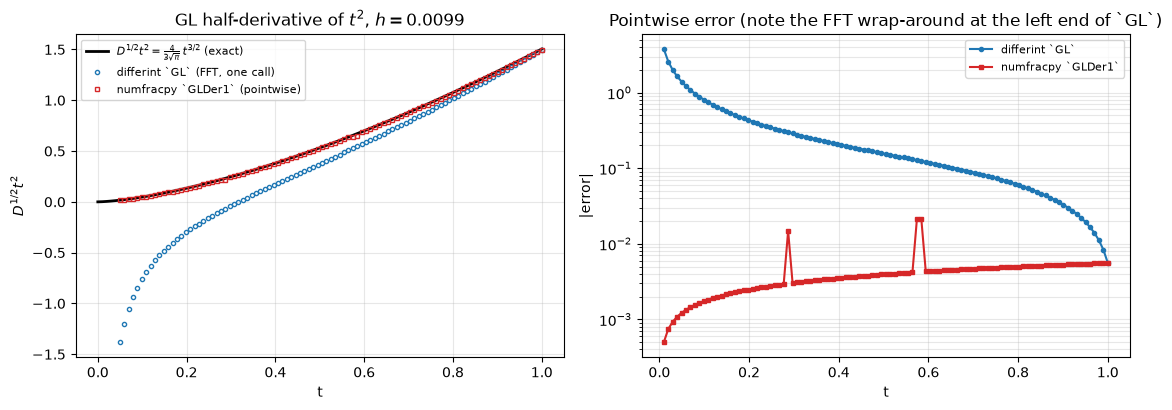

In [3]:
alpha = 0.5
f = lambda t: t**2
exact = lambda t: math.gamma(3.0) / math.gamma(2.5) * t**1.5

n = 102
t = np.linspace(0.0, 1.0, n)
h = t[1] - t[0]

# differint: one call -> whole array (even n -> length n)
gl_dif = GL(alpha, f, 0.0, 1.0, n)
print("differint GL output length for n =", n, ":", len(gl_dif))
gl_odd = GL(alpha, f, 0.0, 1.0, n + 1)
print("differint GL output length for n =", n + 1, ":", len(gl_odd), "  <-- n-1 for odd n!")

# numfracpy: pointwise loop over the same grid
gl_nfp = np.array([nfp.GLDer1(f, tk, h, alpha) for tk in t])

err_dif = np.abs(gl_dif - exact(t))
err_nfp = np.abs(gl_nfp - exact(t))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].plot(t, exact(t), 'k-', lw=2, label=r'$D^{1/2}t^2 = \frac{4}{3\sqrt{\pi}}\,t^{3/2}$ (exact)')
ax[0].plot(t[5:], gl_dif[5:], 'o', ms=3, mfc='none', color='tab:blue', label='differint `GL` (FFT, one call)')
ax[0].plot(t[5:], gl_nfp[5:], 's', ms=3, mfc='none', color='tab:red', label='numfracpy `GLDer1` (pointwise)')
ax[0].set_xlabel('t'); ax[0].set_ylabel(r'$D^{1/2} t^2$')
ax[0].set_title('GL half-derivative of $t^2$, $h = %.4f$' % h)
ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3)

ax[1].semilogy(t[1:], err_dif[1:], 'o-', ms=3, color='tab:blue', label='differint `GL`')
ax[1].semilogy(t[1:], err_nfp[1:], 's-', ms=3, color='tab:red', label='numfracpy `GLDer1`')
ax[1].set_xlabel('t'); ax[1].set_ylabel('|error|')
ax[1].set_title('Pointwise error (note the FFT wrap-around at the left end of `GL`)')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, which='both')
fig.tight_layout()
fig.show()

print("max error on t >= 0.05:  differint %.3e | numfracpy %.3e" %
      (np.max(err_dif[t >= 0.05]), np.max(err_nfp[t >= 0.05])))
print("max error overall:       differint %.3e | numfracpy %.3e" %
      (np.max(err_dif), np.max(err_nfp)))

## 2  Convergence study: error vs grid spacing `h`

Both GL schemes are first order in `h` for a smooth `f`: `err ≈ C·h`.

**Important subtlety.** `differint.GL` computes the convolution with a real FFT, i.e. a *circular*
convolution. For a finite array this wraps the filter tail back onto the left end of the grid, adding
an error that is **not** the discretization error and that *grows with N*. To compare the two
*mathematical* schemes fairly, we compute the differint side as the **linear** convolution with the
same generalized-binomial filter `GLcoeffs(α, N-1)` (exactly the filter `GL` uses internally), and we
report the FFT wrap-around as a separate diagnostic.

For `numfracpy` we use a `t = k·dt` grid (`dt = 1/N`) so the evaluation point `t = 1` always lies
exactly on the grid — see §6 for why this matters.


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\1645222501.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


h            : [0.02    0.01    0.005   0.0025  0.00125]
err differint: ['3.791e-03', '1.899e-03', '9.448e-04', '4.705e-04', '2.354e-04']
err numfracpy: ['4.801e-02', '2.405e-02', '1.292e-02', '6.675e-03', '3.389e-03']
wrap-around  : ['5.749e+00', '8.630e+00', '1.274e+01', '1.857e+01', '2.683e+01']
fitted order: differint 1.00 | numfracpy 0.95  (theory: 1)


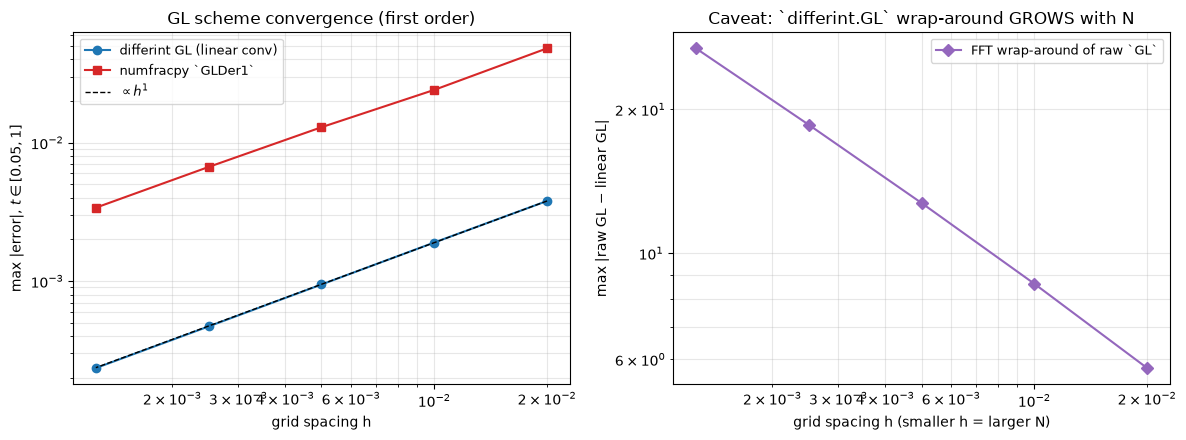

In [4]:
alpha = 0.5
f = lambda t: t**2
exact = lambda t: math.gamma(3.0) / math.gamma(2.5) * t**1.5

Ns = [50, 100, 200, 400, 800]
hs = np.array([1.0 / N for N in Ns])
err_dif, err_nfp, wrap = [], [], []
t_plot = np.linspace(0.05, 1.0, 100)   # error norm over t in [0.05, 1]

for N in Ns:
    h = 1.0 / N
    tv = np.linspace(0.0, 1.0, N)
    fv = tv**2
    # --- differint GL scheme, as a LINEAR convolution (no FFT wrap-around) ---
    b = GLcoeffs(alpha, N - 1)
    lin = np.convolve(fv, b, mode="full")[:N] * h**(-alpha)
    err_dif.append(np.max(np.abs(np.interp(t_plot, tv, lin) - exact(t_plot))))
    # --- numfracpy pointwise GL ---
    err_nfp.append(np.max(np.abs(np.array([nfp.GLDer1(f, tk, h, alpha) for tk in t_plot]) -
                                 exact(t_plot))))
    # --- diagnostic: how big is the FFT wrap-around in the raw `GL` output? ---
    wrap.append(np.max(np.abs(GL(alpha, f, 0.0, 1.0, N) - lin)))

err_dif = np.array(err_dif)
err_nfp = np.array(err_nfp)
order_dif = np.polyfit(np.log(hs), np.log(err_dif), 1)[0]
order_nfp = np.polyfit(np.log(hs), np.log(err_nfp), 1)[0]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].loglog(hs, err_dif, 'o-', color='tab:blue', label='differint GL (linear conv)')
ax[0].loglog(hs, err_nfp, 's-', color='tab:red', label='numfracpy `GLDer1`')
ax[0].loglog(hs, err_dif[0] * (hs / hs[0]), 'k--', lw=1, label=r'$\propto h^1$')
ax[0].set_xlabel('grid spacing h'); ax[0].set_ylabel('max |error|, $t \\in [0.05,1]$')
ax[0].set_title('GL scheme convergence (first order)')
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3, which='both')

ax[1].loglog(hs, np.array(wrap), 'D-', color='tab:purple', label='FFT wrap-around of raw `GL`')
ax[1].set_xlabel('grid spacing h (smaller h = larger N)')
ax[1].set_ylabel('max |raw GL − linear GL|')
ax[1].set_title('Caveat: `differint.GL` wrap-around GROWS with N')
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3, which='both')
fig.tight_layout()
fig.show()

print("h            :", hs)
print("err differint:", ["%.3e" % e for e in err_dif])
print("err numfracpy:", ["%.3e" % e for e in err_nfp])
print("wrap-around  :", ["%.3e" % w for w in wrap])
print(f"fitted order: differint {order_dif:.2f} | numfracpy {order_nfp:.2f}  (theory: 1)")

## 3  Riemann–Liouville derivatives: `differint.RL` vs `numfracpy.RL_der1`

The RL derivative of order `α` is the fractional integral of order `1−α` of the ordinary derivative:

$$D_t^{\alpha} f(t) = \frac{d^{m}}{dt^{m}} I_t^{m-\alpha} f(t), \qquad m-1 < \alpha \le m .$$

`differint.RL` builds the full `n×n` trapezoidal coefficient matrix (Baleanu et al.) and multiplies it by
the sample vector; `numfracpy.RL_der1` uses the `L1`-type weights plus the endpoint singular terms
`f(0)·t^{−α}/Γ(1−α)` (and, for `RL_der2`, `f'(0)·t^{1−α}/Γ(2−α)`).

For `f(t)=t²`, `α=1/2` both converge like `O(h^{3/2})` here (the trapezoidal rule is higher order for this
smooth case).


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\3927089638.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


max |differint - numfracpy| = 0.017260724555302143
error at t=1: differint 4.597e-04 | numfracpy 4.597e-04


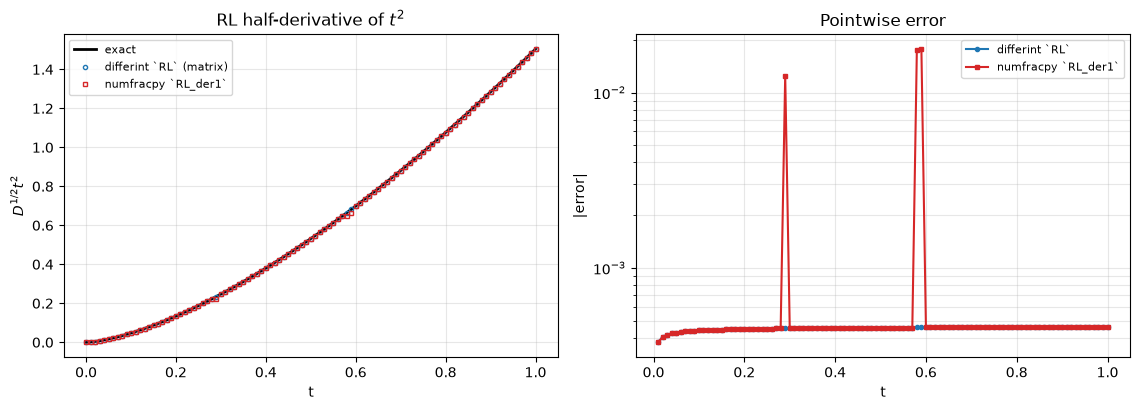

In [5]:
alpha = 0.5
f = lambda t: t**2
exact = lambda t: math.gamma(3.0) / math.gamma(2.5) * t**1.5

N = 100
dt = 1.0 / N
t = np.array([k * dt for k in range(N + 1)])

rl_dif = RL(alpha, f, 0.0, 1.0, N + 1)          # one call -> whole array
# numfracpy pointwise — note: RL_der1 crashes at t = 0 (the f(0)·t^{-α} term), so start at t = dt
rl_nfp = np.empty(N + 1); rl_nfp[0] = 0.0
rl_nfp[1:] = np.array([nfp.RL_der1(f, tk, dt, alpha) for tk in t[1:]])

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].plot(t, exact(t), 'k-', lw=2, label='exact')
ax[0].plot(t, rl_dif, 'o', ms=3, mfc='none', color='tab:blue', label='differint `RL` (matrix)')
ax[0].plot(t, rl_nfp, 's', ms=3, mfc='none', color='tab:red', label='numfracpy `RL_der1`')
ax[0].set_xlabel('t'); ax[0].set_ylabel(r'$D^{1/2} t^2$')
ax[0].set_title('RL half-derivative of $t^2$')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].semilogy(t[1:], np.abs(rl_dif[1:] - exact(t[1:])), 'o-', ms=3, color='tab:blue', label='differint `RL`')
ax[1].semilogy(t[1:], np.abs(rl_nfp[1:] - exact(t[1:])), 's-', ms=3, color='tab:red', label='numfracpy `RL_der1`')
ax[1].set_xlabel('t'); ax[1].set_ylabel('|error|')
ax[1].set_title('Pointwise error')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, which='both')
fig.tight_layout()
fig.show()

print("max |differint - numfracpy| =", np.max(np.abs(rl_dif - rl_nfp)))
print("error at t=1: differint %.3e | numfracpy %.3e" %
      (abs(rl_dif[-1] - exact(1.0)), abs(rl_nfp[-1] - exact(1.0))))

## 4  Caputo derivatives: L1 (0<α<1) and L2 (1<α<2)

The Caputo derivative differentiates *first*, then integrates — so it vanishes on constants, which makes it
the natural choice for initial-value problems. Both libraries implement the standard L1 / L2 schemes
(Karniadakis, *Handbook of Fractional Calculus with Applications*, vol. 3):

* `differint.CaputoL1point(α, f, a, b, n)` / `numfracpy.Caputo_der1(f, t, dt, α)` — `0 < α < 1`
* `differint.CaputoL2point(α, f, a, b, n)` / `numfracpy.Caputo_der2(f, t, dt, α)` — `1 < α < 2`

For `f(t)=t²`, `α=1/2`: exact `C^{1/2} t²|_1 = 4/(3√π) ≈ 1.504506`.

**Grid subtlety:** `CaputoL1point` uses `n` points on `[a, b]` (so the step is `(b−a)/(n−1)`), while
`Caputo_der1` uses `n = int(t/dt)` sub-intervals (step `dt`). To compare on the *same* grid `t_k = k·dt`,
we call the differint version at each `t_k` with `num_points = k+1` (i.e. `a=0, b=t_k, n=k+1`).


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\143572966.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\143572966.py:59: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


L1: max |differint - numfracpy| = 0.017260724555302698
L1: error at t=1  differint 4.597e-04 | numfracpy 4.597e-04
L2: max |differint - numfracpy| = 0.05156087828385658
L2: error at t=1  differint 3.213e-02 | numfracpy 3.247e-02


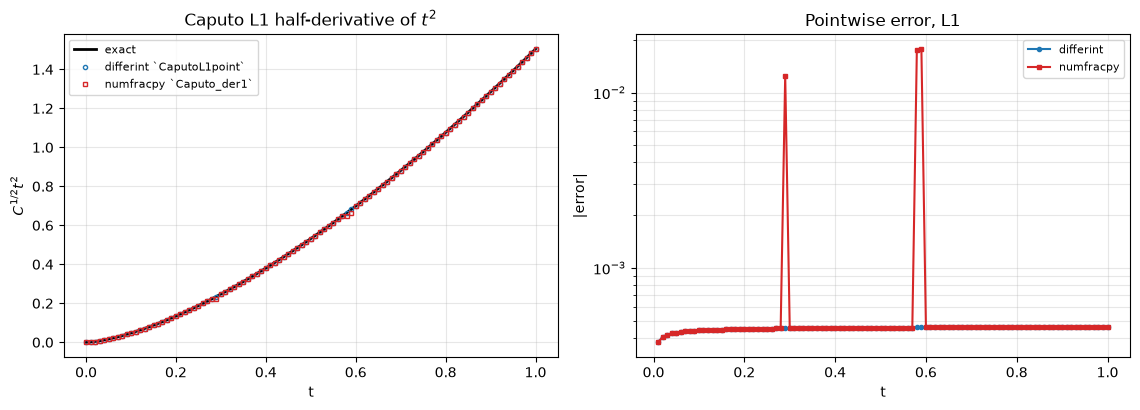

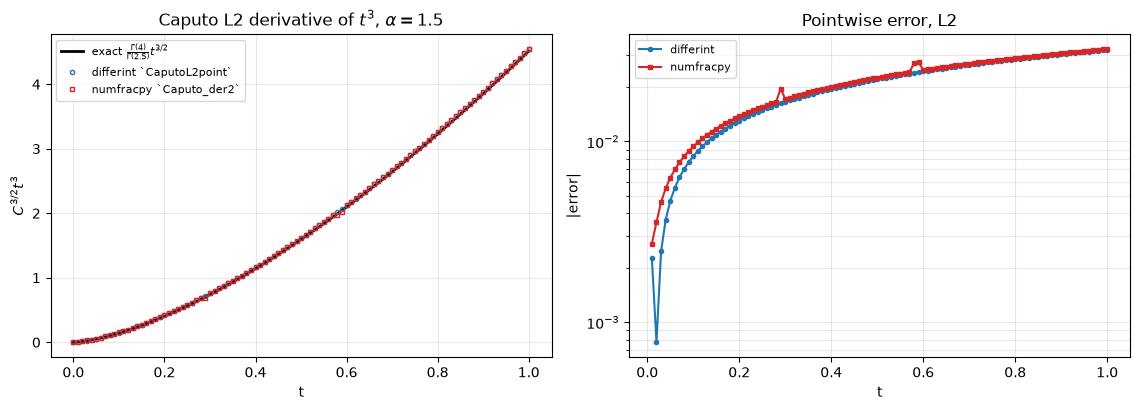

In [6]:
alpha = 0.5
f = lambda t: t**2
exact = lambda t: math.gamma(3.0) / math.gamma(2.5) * t**1.5

N = 100
dt = 1.0 / N
t = np.array([k * dt for k in range(N + 1)])

# --- L1 (0 < alpha < 1) ---
c_dif = np.empty(N + 1); c_dif[0] = 0.0
for k in range(1, N + 1):
    c_dif[k] = CaputoL1point(alpha, f, 0.0, t[k], k + 1)
c_nfp = np.array([nfp.Caputo_der1(f, tk, dt, alpha) for tk in t])

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].plot(t, exact(t), 'k-', lw=2, label='exact')
ax[0].plot(t, c_dif, 'o', ms=3, mfc='none', color='tab:blue', label='differint `CaputoL1point`')
ax[0].plot(t, c_nfp, 's', ms=3, mfc='none', color='tab:red', label='numfracpy `Caputo_der1`')
ax[0].set_xlabel('t'); ax[0].set_ylabel(r'$C^{1/2} t^2$')
ax[0].set_title('Caputo L1 half-derivative of $t^2$')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].semilogy(t[1:], np.abs(c_dif[1:] - exact(t[1:])), 'o-', ms=3, color='tab:blue', label='differint')
ax[1].semilogy(t[1:], np.abs(c_nfp[1:] - exact(t[1:])), 's-', ms=3, color='tab:red', label='numfracpy')
ax[1].set_xlabel('t'); ax[1].set_ylabel('|error|')
ax[1].set_title('Pointwise error, L1')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, which='both')
fig.tight_layout()
fig.show()

print("L1: max |differint - numfracpy| =", np.max(np.abs(c_dif - c_nfp)))
print("L1: error at t=1  differint %.3e | numfracpy %.3e" %
      (abs(c_dif[-1] - exact(1.0)), abs(c_nfp[-1] - exact(1.0))))

# --- L2 (1 < alpha < 2) ---
alpha2 = 1.5
g = lambda t: t**3
exact2 = lambda t: math.gamma(4.0) / math.gamma(3.0 - alpha2 + 1.0) * t**(3.0 - alpha2)  # Γ(4)/Γ(2.5) t^1.5

c2_dif = np.empty(N + 1); c2_dif[0] = 0.0
for k in range(1, N + 1):
    c2_dif[k] = CaputoL2point(alpha2, g, 0.0, t[k], k + 1)
c2_nfp = np.array([nfp.Caputo_der2(g, tk, dt, alpha2) for tk in t])

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].plot(t, exact2(t), 'k-', lw=2, label=r'exact $\frac{\Gamma(4)}{\Gamma(2.5)}t^{3/2}$')
ax[0].plot(t, c2_dif, 'o', ms=3, mfc='none', color='tab:blue', label='differint `CaputoL2point`')
ax[0].plot(t, c2_nfp, 's', ms=3, mfc='none', color='tab:red', label='numfracpy `Caputo_der2`')
ax[0].set_xlabel('t'); ax[0].set_ylabel(r'$C^{3/2} t^3$')
ax[0].set_title(r'Caputo L2 derivative of $t^3$, $\alpha = 1.5$')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].semilogy(t[1:], np.abs(c2_dif[1:] - exact2(t[1:])), 'o-', ms=3, color='tab:blue', label='differint')
ax[1].semilogy(t[1:], np.abs(c2_nfp[1:] - exact2(t[1:])), 's-', ms=3, color='tab:red', label='numfracpy')
ax[1].set_xlabel('t'); ax[1].set_ylabel('|error|')
ax[1].set_title('Pointwise error, L2')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, which='both')
fig.tight_layout()
fig.show()

print("L2: max |differint - numfracpy| =", np.max(np.abs(c2_dif - c2_nfp)))
print("L2: error at t=1  differint %.3e | numfracpy %.3e" %
      (abs(c2_dif[-1] - exact2(1.0)), abs(c2_nfp[-1] - exact2(1.0))))

## 4.1  RL vs Caputo — the constant function

The defining practical difference:

* `C^{α} 1 = 0` for any `α > 0` (Caputo differentiates first, and `1' = 0`),
* `D^{α}_{RL} 1 = t^{−α}/Γ(1−α)` — a **non-integrable-looking singularity at `t = 0`** (RL differentiates a
  distribution-like extension of the constant).

Both libraries reproduce this exactly — and note that `differint`'s `RLpoint`/`RL` also accept **negative
orders** (fractional integrals), which `numfracpy`'s `RL_der*` functions do not.


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\859151585.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


RL : max |differint - numfracpy| = 0.026225654284907973
RL : max |numfracpy - exact|     = 0.026225654284902644
Caputo: max |differint| = 0.0  max |numfracpy| = 0.0


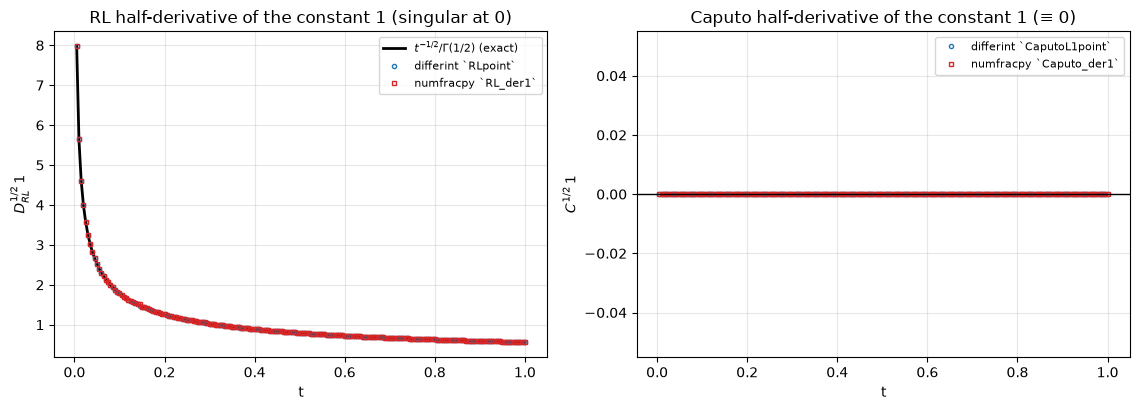

In [7]:
alpha = 0.5
one = lambda t: 1.0

N = 200
dt = 1.0 / N
t = np.array([k * dt for k in range(1, N + 1)])   # avoid t = 0 for the RL singularity

rl_dif = np.array([RLpoint(alpha, one, 0.0, tk, int(round(tk / dt)) + 1) for tk in t])
rl_nfp = np.array([nfp.RL_der1(one, tk, dt, alpha) for tk in t])
c_dif = np.array([CaputoL1point(alpha, one, 0.0, tk, int(round(tk / dt)) + 1) for tk in t])
c_nfp = np.array([nfp.Caputo_der1(one, tk, dt, alpha) for tk in t])
exact_rl = t**(-alpha) / math.gamma(1.0 - alpha)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].plot(t, exact_rl, 'k-', lw=2, label=r'$t^{-1/2}/\Gamma(1/2)$ (exact)')
ax[0].plot(t, rl_dif, 'o', ms=3, mfc='none', color='tab:blue', label='differint `RLpoint`')
ax[0].plot(t, rl_nfp, 's', ms=3, mfc='none', color='tab:red', label='numfracpy `RL_der1`')
ax[0].set_xlabel('t'); ax[0].set_ylabel(r'$D^{1/2}_{RL}\, 1$')
ax[0].set_title('RL half-derivative of the constant 1 (singular at 0)')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(t, c_dif, 'o', ms=3, mfc='none', color='tab:blue', label='differint `CaputoL1point`')
ax[1].plot(t, c_nfp, 's', ms=3, mfc='none', color='tab:red', label='numfracpy `Caputo_der1`')
ax[1].axhline(0.0, color='k', lw=1)
ax[1].set_xlabel('t'); ax[1].set_ylabel(r'$C^{1/2}\, 1$')
ax[1].set_title('Caputo half-derivative of the constant 1 (≡ 0)')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.show()

print("RL : max |differint - numfracpy| =", np.max(np.abs(rl_dif - rl_nfp)))
print("RL : max |numfracpy - exact|     =", np.max(np.abs(rl_nfp - exact_rl)))
print("Caputo: max |differint| =", np.max(np.abs(c_dif)), " max |numfracpy| =", np.max(np.abs(c_nfp)))

## 5  Fractional integrals (negative order)

`differint` handles integrals by passing a **negative order** to the same functions:
`I^{1/2} f(t) = D^{−1/2} f(t)`. `numfracpy` has a dedicated `RL_integral(f, a, t, α)` that evaluates the
integral with `scipy.integrate.quad` — accurate to machine precision, but slow (one quadrature per point).

Test: `I^{1/2} 1 = t^{1/2}/Γ(3/2) = 2√t/√π` and `I^{1/2} t² = Γ(3)/(Γ(2.5)Γ(3.5))·t^{2.5}`.


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\4108630527.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


I^{1/2}1 at t=1  exact 1.128379 | GL(-0.5) 1.132563 (err 4.18e-03) | RL(-0.5) 1.128379 (err 6.73e-14) | nfp quad 1.128379 (err 6.66e-14)
I^{1/2}t^2 at t=1 exact 0.452707 | differint RL(-0.5) 0.601820 (err 1.49e-01)


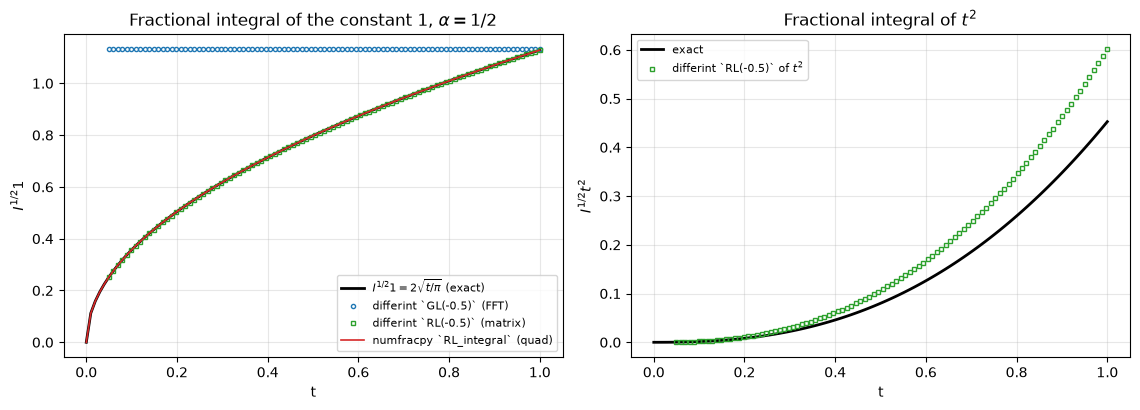

In [8]:
alpha = 0.5

n = 102
t = np.linspace(0.0, 1.0, n)
h = t[1] - t[0]

# --- integral of the constant ---
exact_const = t**0.5 / math.gamma(1.5)
ri_gl = GL(-alpha, lambda x: 1.0, 0.0, 1.0, n)            # differint, negative order (FFT)
ri_rl = RL(-alpha, lambda x: 1.0, 0.0, 1.0, n)            # differint, negative order (matrix)
ri_nfp = np.array([nfp.RL_integral(lambda s: 1.0, 0.0, tk, alpha) for tk in t])  # quad per point

# --- integral of t^2 ---
exact_t2 = t**2.5 * math.gamma(3.0) / (math.gamma(2.5) * math.gamma(3.5))
ri_t2 = RL(-alpha, lambda x: x**2, 0.0, 1.0, n)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].plot(t, exact_const, 'k-', lw=2, label=r'$I^{1/2}1 = 2\sqrt{t/\pi}$ (exact)')
ax[0].plot(t[5:], ri_gl[5:], 'o', ms=3, mfc='none', color='tab:blue', label='differint `GL(-0.5)` (FFT)')
ax[0].plot(t[5:], ri_rl[5:], 's', ms=3, mfc='none', color='tab:green', label='differint `RL(-0.5)` (matrix)')
ax[0].plot(t, ri_nfp, '-', lw=1.2, color='tab:red', label='numfracpy `RL_integral` (quad)')
ax[0].set_xlabel('t'); ax[0].set_ylabel(r'$I^{1/2} 1$')
ax[0].set_title(r'Fractional integral of the constant 1, $\alpha = 1/2$')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(t, exact_t2, 'k-', lw=2, label='exact')
ax[1].plot(t[5:], ri_t2[5:], 's', ms=3, mfc='none', color='tab:green', label='differint `RL(-0.5)` of $t^2$')
ax[1].set_xlabel('t'); ax[1].set_ylabel(r'$I^{1/2} t^2$')
ax[1].set_title('Fractional integral of $t^2$')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.show()

print("I^{1/2}1 at t=1  exact %.6f | GL(-0.5) %.6f (err %.2e) | RL(-0.5) %.6f (err %.2e) | nfp quad %.6f (err %.2e)"
      % (exact_const[-1], ri_gl[-1], abs(ri_gl[-1] - exact_const[-1]),
         ri_rl[-1], abs(ri_rl[-1] - exact_const[-1]),
         ri_nfp[-1], abs(ri_nfp[-1] - exact_const[-1])))
print("I^{1/2}t^2 at t=1 exact %.6f | differint RL(-0.5) %.6f (err %.2e)"
      % (exact_t2[-1], ri_t2[-1], abs(ri_t2[-1] - exact_t2[-1])))

## 6  Pitfalls we actually hit (read this!)

1. **`differint` import**: `__init__.py` declares `__all__` but imports nothing →
   `from differint import GL` **fails**. Use `from differint.differint import …` (shown in cell 0).
2. **`differint.PCsolver` is broken on numpy ≥ 2**: it allocates `np.zeros(n, dtype='complex_')` and
   `complex_` was removed in numpy 2.0 → `TypeError`. It also only supports `α > 1`
   (raises `ValueError('Not yet supported!')` for `α < 1`). A one-line patch restores it (§7).
3. **`numfracpy` error handling**: out-of-range orders return **strings** like
   `"alpha cannot be greater or equal than one"` instead of raising exceptions — `abs()` on such a
   "result" raises a confusing `TypeError` downstream.
4. **`numfracpy` grid snapping**: every pointwise function does `n = int(t/dt)` and then **silently
   re-evaluates at `t = n·dt`**. If `t` is not on the `k·dt` grid you get the answer at a *different*
   point, with no warning (demonstrated below). Always build your grid as `t = k·dt`.
5. **`differint.GL` output length & wrap-around**: `rfft`/`irfft` padding makes the array length `n`
   for even `n` and `n−1` for odd `n` (§1), and the circular convolution wraps the filter tail back
   onto the grid — a long-range error that **grows with N** (§2). Use `GLpoint` for single points or
   apply the linear-convolution correction if you need the whole array at high resolution.
6. **`numfracpy.GLDer2` / `RL_der2` (1<α<2) evaluate `f` at negative times** (`f((n−j+p)·dt)` reaches
   `f(−dt)`), so they only work for functions that can be extended to `t < 0` (e.g. polynomials) —
   they will misbehave or crash on `f(t) = √t` or `log(1+t)`.
7. **`numfracpy.SystemFODEs` returns Python lists** (and prints `N_ = …` to stdout); wrap with
   `np.asarray` and `contextlib.redirect_stdout` as in §8.
8. **`differint.MittagLeffler` series** only accepts **array** input (a float `z` raises `AxisError`),
   and **diverges in floating point for large negative real `z`** (terms overflow before the gamma
   function tames them) — §7 shows the LT-inversion evaluator staying accurate there. Conversely,
   numfracpy's `Mittag_Leffler_one` returns `nan` for large positive `z` (residue overflow).


In [9]:
# (3) numfracpy returns strings, not exceptions
print("RL_der1(alpha=1.5)  ->", repr(nfp.RL_der1(lambda x: x, 1.0, 0.01, 1.5)))
print("RL_integral(alpha=0)->", repr(nfp.RL_integral(lambda x: x, 0.0, 1.0, 0.0)))
try:
    abs(nfp.RL_der1(lambda x: x, 1.0, 0.01, 1.5))
except TypeError as e:
    print("and abs() on that 'result' ->", type(e).__name__, ":", e)

# differint instead raises AssertionError with a message
try:
    GL(0.5, lambda x: x**2, 0.0, 1.0, 100.5)
except AssertionError as e:
    print("differint GL(num_points=100.5) -> AssertionError:", e)

# (4) silent grid snapping: t = 0.5001 with dt = 0.1 is silently moved to t = 0.5
a = nfp.GLDer1(lambda x: x**2, 0.5, 0.1, 0.5)
b = nfp.GLDer1(lambda x: x**2, 0.5001, 0.1, 0.5)
print("\nGLDer1(t=0.5,    dt=0.1) =", a)
print("GLDer1(t=0.5001, dt=0.1) =", b, "  <-- identical: t was snapped to 0.5, no warning")

RL_der1(alpha=1.5)  -> 'alpha cannot be greater or equal than one'
RL_integral(alpha=0)-> 'alpha cannot be less or equal than zero'
and abs() on that 'result' -> TypeError : bad operand type for abs(): 'str'
differint GL(num_points=100.5) -> AssertionError: num_points is not an integer: 100.5

GLDer1(t=0.5,    dt=0.1) = 0.4928706196903059
GLDer1(t=0.5001, dt=0.1) = 0.4928706196903059   <-- identical: t was snapped to 0.5, no warning


## 7  Mittag-Leffler functions — series vs Laplace inversion

The Mittag-Leffler function is the fractional-calculus analogue of the exponential:

$$E_{\alpha,\beta}(z) = \sum_{k=0}^{\infty} \frac{z^k}{\Gamma(\alpha k + \beta)}, \qquad E_{1,1}(z) = e^z .$$

* **`differint.MittagLeffler(a, b, x, num_terms)`** — plain power series, vectorised over `x`, with
  closed-form shortcuts for the special cases `(a,b) ∈ {(1,1), (2,1), (1,2), (2,2), (0,·)}`.
  Fast and accurate for moderate `|z|`. **Two bugs to know:** (i) it only accepts **array** `x` —
  a Python float raises `AxisError` (scalar handling is broken in the series branch); (ii) the
  series **diverges in floating point for large negative real `z`** (terms grow before the gamma
  function can tame them) — see the plot below.
* **`numfracpy.Mittag_Leffler_one(z, α)`** (and `two`, `three`) — **inverse Laplace transform** via a
  Talbot-type contour integral with optimised parameters (Mastroianni–Napolitano), scalar in `z`.
  Stays accurate where the series blows up (large negative `z`), but one call per point and
  `nan` for large positive `z` (residue-sum overflow).
* **`numfracpy.MittagLeffler_one_fsum(z, α, Nmax)`** — naive series, shown for reference.

We compare all three on `E_{1/2}(z)` for `z ∈ [−8, 4]` and check the special cases of `differint`
against `exp` and `cosh`.


MittagLeffler(scalar z) raises AxisError - pass an array instead
z= -8.0:  series = -2.061584e+11   LT =  6.998517e-02   |diff| = 2.062e+11
z= -6.0:  series = -3.695005e-01   LT =  9.277657e-02   |diff| = 4.623e-01
z= -4.0:  series =  1.369995e-01   LT =  1.369995e-01   |diff| = 6.019e-10
z=  0.0:  series =  1.000000e+00   LT =  1.000000e+00   |diff| = 1.998e-15
z=  4.0:  series =  1.777222e+07   LT =  1.777222e+07   |diff| = 3.725e-09

special cases:  max|E_{1,1} - exp| = 0.0    max|E_{2,1} - cosh(√z)| = 0.0
LT inversion at z = 50 (large positive): nan   <-- residue overflow -> nan


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\4048632440.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


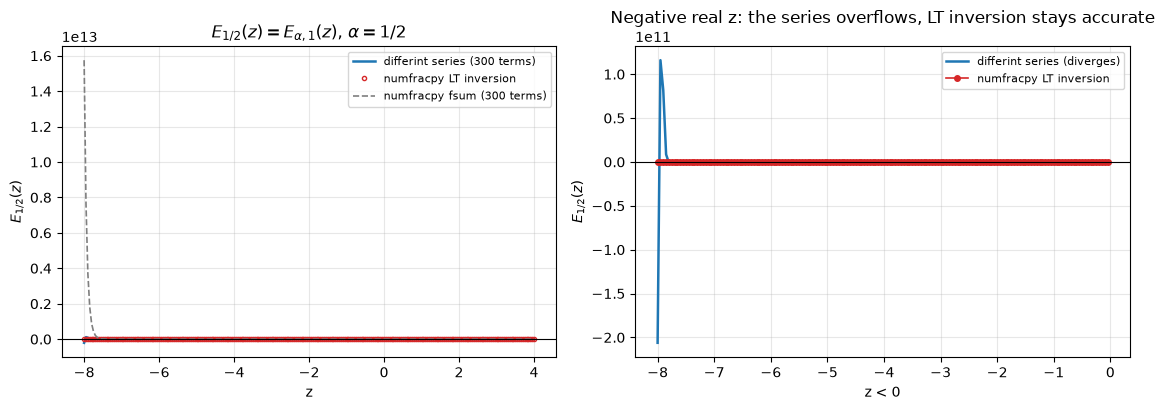

In [10]:
z = np.linspace(-8.0, 4.0, 241)

# differint: one vectorised call (series, 300 terms) — NOTE: x must be an array, not a scalar
ml_dif = MittagLeffler(0.5, 1.0, z, num_terms=300)

# numfracpy: LT inversion, pointwise (suppress the overflow warnings inside the residue sum)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    ml_lt = np.array([nfp.Mittag_Leffler_one(zz, 0.5) for zz in z])
# numfracpy: naive series
ml_fsum = np.array([nfp.MittagLeffler_one_fsum(zz, 0.5, 300) for zz in z])

# special cases (differint shortcuts)
zpos = np.linspace(0.0, 4.0, 101)
sp1 = np.max(np.abs(MittagLeffler(1.0, 1.0, zpos, 50) - np.exp(zpos)))
sp2 = np.max(np.abs(MittagLeffler(2.0, 1.0, zpos, 50) - np.cosh(np.sqrt(zpos))))

# the scalar-input bug, demonstrated
try:
    MittagLeffler(0.5, 1.0, -4.0, num_terms=300)
    print("MittagLeffler scalar input: OK")
except Exception as e:
    print("MittagLeffler(scalar z) raises", type(e).__name__, "- pass an array instead")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].plot(z, ml_dif, '-', lw=1.8, color='tab:blue', label='differint series (300 terms)')
ax[0].plot(z, ml_lt, 'o', ms=3, mfc='none', color='tab:red', label='numfracpy LT inversion')
ax[0].plot(z, ml_fsum, '--', lw=1.2, color='tab:gray', label='numfracpy fsum (300 terms)')
ax[0].axhline(0, color='k', lw=0.8)
ax[0].set_xlabel('z'); ax[0].set_ylabel(r'$E_{1/2}(z)$')
ax[0].set_title(r'$E_{1/2}(z) = E_{\alpha,1}(z)$, $\alpha = 1/2$')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

# zoom on the negative-z part, where the two approaches disagree violently
ax[1].plot(z[z < 0], ml_dif[z < 0], '-', lw=1.8, color='tab:blue', label='differint series (diverges)')
ax[1].plot(z[z < 0], ml_lt[z < 0], 'o-', ms=4, lw=1.2, color='tab:red', label='numfracpy LT inversion')
ax[1].axhline(0, color='k', lw=0.8)
ax[1].set_xlabel('z < 0'); ax[1].set_ylabel(r'$E_{1/2}(z)$')
ax[1].set_title('Negative real z: the series overflows, LT inversion stays accurate')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.show()

for zt in [-8.0, -6.0, -4.0, 0.0, 4.0]:
    s = float(MittagLeffler(0.5, 1.0, np.array([zt]), num_terms=300)[0])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        lt = nfp.Mittag_Leffler_one(zt, 0.5)
    print(f"z={zt:5.1f}:  series = {s: .6e}   LT = {lt: .6e}   |diff| = {abs(s-lt):.3e}")

print()
print("special cases:  max|E_{1,1} - exp| =", sp1, "   max|E_{2,1} - cosh(√z)| =", sp2)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    print("LT inversion at z = 50 (large positive):", nfp.Mittag_Leffler_one(50.0, 0.5), "  <-- residue overflow -> nan")

## 8  Solving fractional ODEs

### 8.1  `numfracpy.FODE` — Caputo IVP via Adams predictor–corrector

$$C^{\alpha} y(t) = f(t, y(t)), \qquad y(0) = y_0 .$$

Test problem: `D^{1/2} y = −y`, `y(0) = 1`. The exact solution is
`y(t) = E_{1/2}(−√t)` — which we evaluate with numfracpy's own LT inversion, closing the loop with §7.


max |y - exact| = 0.0008066330471104832
y(1) numeric 0.427613 vs exact 0.427584


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\2466788170.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


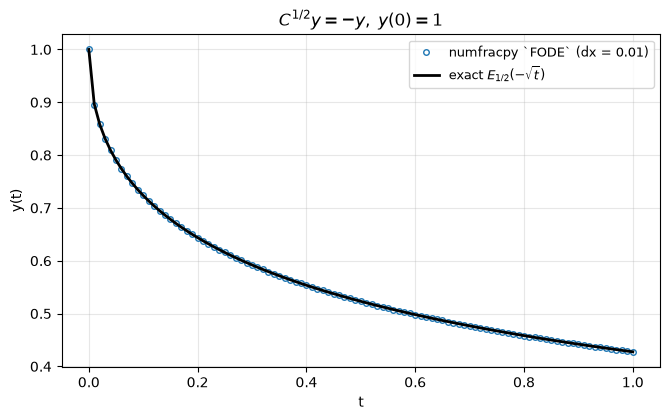

In [11]:
alpha = 0.5
x, y = nfp.FODE(lambda t, u: -u, [1.0], [0, 1.0], 0.01, alpha)
y_exact = np.array([nfp.Mittag_Leffler_one(-tt**0.5, alpha) for tt in x])

fig, ax = plt.subplots(figsize=(6.8, 4.3))
ax.plot(x, y, 'o', ms=4, mfc='none', color='tab:blue', label='numfracpy `FODE` (dx = 0.01)')
ax.plot(x, y_exact, 'k-', lw=2, label=r'exact $E_{1/2}(-\sqrt{t})$')
ax.set_xlabel('t'); ax.set_ylabel('y(t)')
ax.set_title(r'$C^{1/2}y = -y,\; y(0)=1$')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.show()

print("max |y - exact| =", np.max(np.abs(y - y_exact)))
print("y(1) numeric %.6f vs exact %.6f" % (y[-1], y_exact[-1]))

### 8.2  Convergence of `FODE` in the step `dx`

The Adams P-C scheme is nominally second order in `dx` — but only when the solution is smooth enough.
Here `y(t) = E_{1/2}(−√t)` has a **weak singularity at `t = 0`** (`y'(t) ~ t^{−1/2}`), which degrades
the observed order to roughly `O(dx^{2/3})`. That is a property of the *problem*, not a bug in the
solver — the fitted slope below tells the honest story.


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\650866620.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


dx  : [0.02, 0.01, 0.005, 0.0025]
err : ['1.080e-03', '8.066e-04', '5.019e-04', '2.869e-04']
fitted order: 0.64  (nominal: 2, degraded by the $t^{-1/2}$ behaviour of $y'$ at 0)


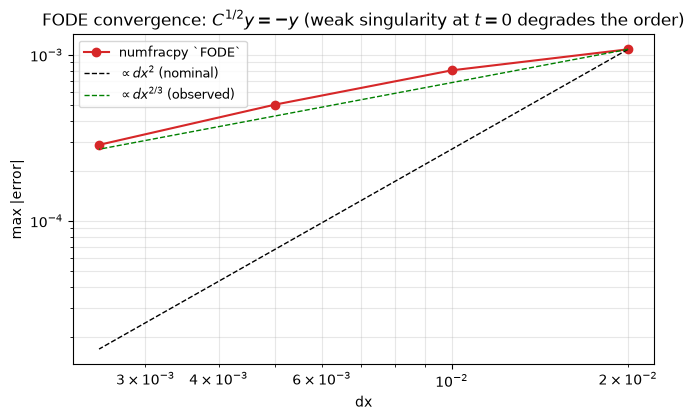

In [12]:
dxs = [0.02, 0.01, 0.005, 0.0025]
errs = []
for dx in dxs:
    x, y = nfp.FODE(lambda t, u: -u, [1.0], [0, 1.0], dx, 0.5)
    ye = np.array([nfp.Mittag_Leffler_one(-tt**0.5, 0.5) for tt in x])
    errs.append(np.max(np.abs(y - ye)))
errs = np.array(errs)
order = np.polyfit(np.log(dxs), np.log(errs), 1)[0]

fig, ax = plt.subplots(figsize=(6.8, 4.3))
ax.loglog(dxs, errs, 'o-', color='tab:red', label='numfracpy `FODE`')
ax.loglog(dxs, errs[0] * (np.array(dxs) / dxs[0])**2, 'k--', lw=1, label=r'$\propto dx^2$ (nominal)')
ax.loglog(dxs, errs[0] * (np.array(dxs) / dxs[0])**(2.0/3.0), 'g--', lw=1, label=r'$\propto dx^{2/3}$ (observed)')
ax.set_xlabel('dx'); ax.set_ylabel('max |error|')
ax.set_title('FODE convergence: $C^{1/2}y = -y$ (weak singularity at $t=0$ degrades the order)')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
fig.show()

print("dx  :", dxs)
print("err :", ["%.3e" % e for e in errs])
print(f"fitted order: {order:.2f}  (nominal: 2, degraded by the $t^{{-1/2}}$ behaviour of $y'$ at 0)")

### 8.3  `differint.PCsolver` — the same job, with a numpy-2.x patch

`differint` ships a predictor–corrector solver too, but as noted in §6 it is **broken on numpy ≥ 2**
(`dtype='complex_'`) and only supports `α > 1`. We patch the one broken line in-memory and verify it on
the solver's own docstring example: `D^{3/2} y = y − t − 1`, `y(0) = 1`, `y′(0) = 1` — the equation is
constructed so that `y(t) = t + 1` is the exact solution.


allclose to t + 1: True   max err: 6.217248937900877e-15
PCsolver(alpha=0.5) -> ValueError: Not yet supported!


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\2856876798.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


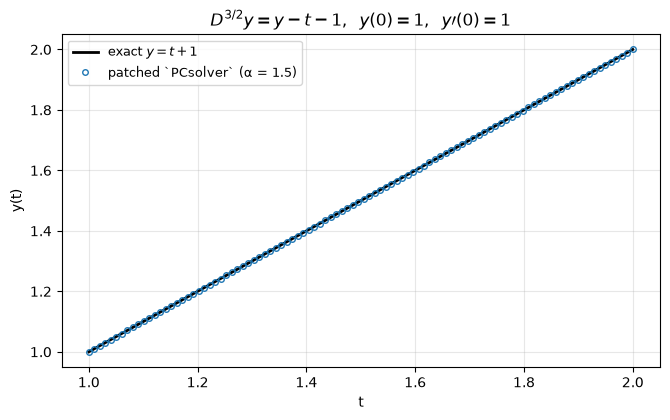

In [13]:
import inspect

src = inspect.getsource(PCsolver).replace("dtype='complex_'", "dtype=complex")
ns = {"np": np,
      "Gamma": __import__('differint.differint', fromlist=['Gamma']).Gamma,
      "PCcoeffs": __import__('differint.differint', fromlist=['PCcoeffs']).PCcoeffs}
exec(src, ns)
PCsolver_fixed = ns["PCsolver"]

# docstring test: D^{1.5} y = y - x - 1, y(0)=1, y'(0)=1  ->  y = x + 1
y_solved = PCsolver_fixed([1.0, 1.0], 1.5, lambda x, y: y - x - 1, 0.0, 1.0, 100)
theoretical = np.linspace(0.0, 1.0, 100) + 1.0

fig, ax = plt.subplots(figsize=(6.8, 4.3))
ax.plot(theoretical, theoretical, 'k-', lw=2, label='exact $y = t + 1$')
ax.plot(theoretical, np.real(y_solved), 'o', ms=4, mfc='none', color='tab:blue',
        label='patched `PCsolver` (α = 1.5)')
ax.set_xlabel('t'); ax.set_ylabel('y(t)')
ax.set_title(r'$D^{3/2}y = y - t - 1,\;\; y(0)=1,\;\; y\prime(0)=1$')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.show()

print("allclose to t + 1:", np.allclose(y_solved, theoretical),
      "  max err:", np.max(np.abs(y_solved - theoretical)))

# and the limitation: alpha < 1 is not implemented
try:
    PCsolver_fixed([1.0], 0.5, lambda x, y: y, 0.0, 1.0, 100)
except ValueError as e:
    print("PCsolver(alpha=0.5) -> ValueError:", e)

### 8.4  A system: fractional Lotka–Volterra with `numfracpy.SystemFODEs`

`SystemFODEs` solves coupled Caputo IVPs, **with a different fractional order per equation** — something
`differint` has no equivalent for. We run the classical predator–prey system

$$C^{\alpha} u = u(1 - v), \qquad C^{\alpha} v = v(u - 1), \qquad u(0)=0.5,\; v(0)=1.5,$$

with `α = 0.9`. For `α = 1` the orbits are the closed LV cycles around `(1, 1)`; for `α < 1` the
trajectories spiral **inward** toward the equilibrium (fractional dynamics has memory, which damps the
oscillations). We compare both in one figure.


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\247827057.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


fractional system: u(10) = 1.0854, v(10) = 0.8435  (spiralling toward (1,1))
integer system:    u(10) = 1.2890, v(10) = 0.4294  (still cycling)


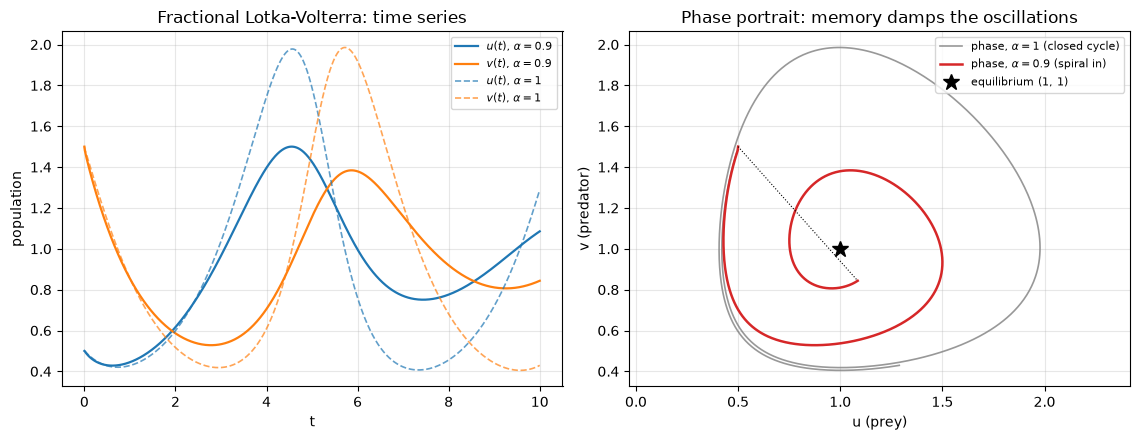

In [14]:
f_sys = [
    lambda s: s[1] * (1.0 - s[2]),    # s = [t, u, v]
    lambda s: s[2] * (s[1] - 1.0),
]

# fractional system (alpha = 0.9)
with contextlib.redirect_stdout(io.StringIO()):
    x_fr, ysol_fr = nfp.SystemFODEs(f_sys, [0.5, 1.5], [0, 10], 0.01, [0.9, 0.9])
x_fr = np.asarray(x_fr); ysol_fr = [np.asarray(y) for y in ysol_fr]

# integer-order reference (alpha = 1)
with contextlib.redirect_stdout(io.StringIO()):
    x_in, ysol_in = nfp.SystemFODEs(f_sys, [0.5, 1.5], [0, 10], 0.01, [1.0, 1.0])
x_in = np.asarray(x_in); ysol_in = [np.asarray(y) for y in ysol_in]

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.5))
ax[0].plot(x_fr, ysol_fr[0], '-', lw=1.6, color='tab:blue', label=r'$u(t)$, $\alpha=0.9$')
ax[0].plot(x_fr, ysol_fr[1], '-', lw=1.6, color='tab:orange', label=r'$v(t)$, $\alpha=0.9$')
ax[0].plot(x_in, ysol_in[0], '--', lw=1.2, color='tab:blue', alpha=0.7, label=r'$u(t)$, $\alpha=1$')
ax[0].plot(x_in, ysol_in[1], '--', lw=1.2, color='tab:orange', alpha=0.7, label=r'$v(t)$, $\alpha=1$')
ax[0].set_xlabel('t'); ax[0].set_ylabel('population')
ax[0].set_title('Fractional Lotka-Volterra: time series')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(ysol_in[0], ysol_in[1], '-', lw=1.2, color='tab:gray', alpha=0.8, label=r'phase, $\alpha=1$ (closed cycle)')
ax[1].plot(ysol_fr[0], ysol_fr[1], '-', lw=1.8, color='tab:red', label=r'phase, $\alpha=0.9$ (spiral in)')
ax[1].plot(1.0, 1.0, 'k*', ms=12, label='equilibrium (1, 1)')
ax[1].plot([0.5, ysol_fr[0][-1]], [1.5, ysol_fr[1][-1]], 'k:', lw=0.8)
ax[1].set_xlabel('u (prey)'); ax[1].set_ylabel('v (predator)')
ax[1].set_title('Phase portrait: memory damps the oscillations')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3); ax[1].set_aspect('equal', adjustable='datalim')
fig.tight_layout()
fig.show()

print("fractional system: u(10) = %.4f, v(10) = %.4f  (spiralling toward (1,1))" %
      (ysol_fr[0][-1], ysol_fr[1][-1]))
print("integer system:    u(10) = %.4f, v(10) = %.4f  (still cycling)" %
      (ysol_in[0][-1], ysol_in[1][-1]))

## 9  Performance

**Complexity picture**

| Task | `differint` | `numfracpy` |
|---|---|---|
| full GL array, `n` points | one FFT: `O(n log n)` | `n` pointwise sums: `O(n²)` |
| full RL array, `n` points | `n×n` matrix–vector: `O(n²)` memory `O(n²)` | `n` pointwise sums: `O(n²)` |
| one point at index `n` | build the grid anyway (`O(n)` for `GLpoint`) | `O(n)` |
| fractional integral | same as derivative, negative order | `quad` per point: `O(n · cost_quad)` |
| FODE on `[0, T]`, step `dx` | `PCsolver` (α>1 only, patched) | `FODE`: `O((T/dx)²)` |
| ML function | vectorised series, one call | scalar LT inversion, one call per point |

Timings below are single runs on this machine; treat them as ratios, not absolute numbers.


     n |   GL differint |   GL numfracpy |   RL differint |   RL numfracpy   (all times in ms)
----------------------------------------------------------------------------------------
   200 |           0.23 |           6.26 |          13.41 |          23.22
  1000 |           1.09 |         175.83 |         373.67 |         580.71
  2000 |           1.29 |         750.39 |        1428.19 |        2440.41

FODE  (T=1, dx=0.01)                    :       12.1 ms   (numfracpy)
SystemFODEs (2 eq, T=10, dx=0.01)        :     3217.7 ms   (numfracpy)


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_25956\715157523.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


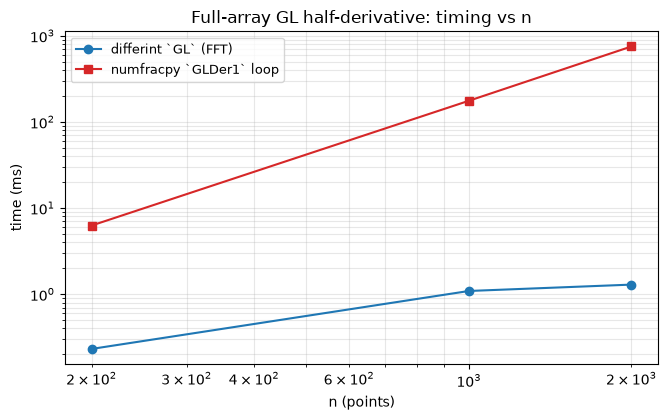

In [15]:
f = lambda t: t**2
alpha = 0.5

rows = []
for n in [200, 1000, 2000]:
    h = 1.0 / (n - 1)
    grid = np.linspace(0.0, 1.0, n)

    t0 = time.perf_counter()
    GL(alpha, f, 0.0, 1.0, n)
    t_gl_dif = time.perf_counter() - t0

    t0 = time.perf_counter()
    [nfp.GLDer1(f, tk, h, alpha) for tk in grid[1:]]
    t_gl_nfp = time.perf_counter() - t0

    t0 = time.perf_counter()
    RL(alpha, f, 0.0, 1.0, n)
    t_rl_dif = time.perf_counter() - t0

    t0 = time.perf_counter()
    [nfp.RL_der1(f, tk, h, alpha) for tk in grid[1:]]
    t_rl_nfp = time.perf_counter() - t0

    rows.append((n, t_gl_dif * 1e3, t_gl_nfp * 1e3, t_rl_dif * 1e3, t_rl_nfp * 1e3))

t0 = time.perf_counter()
nfp.FODE(lambda t, u: -u, [1.0], [0, 1.0], 0.01, 0.5)
t_fode = time.perf_counter() - t0

with contextlib.redirect_stdout(io.StringIO()):
    t0 = time.perf_counter()
    nfp.SystemFODEs([lambda s: s[1] * (1 - s[2]), lambda s: s[2] * (s[1] - 1.0)],
                    [0.5, 1.5], [0, 10], 0.01, [0.9, 0.9])
    t_sys = time.perf_counter() - t0

hdr = f"{'n':>6} | {'GL differint':>14} | {'GL numfracpy':>14} | {'RL differint':>14} | {'RL numfracpy':>14}"
print(hdr + "   (all times in ms)")
print("-" * (len(hdr) + 14))
for n, a, b, c, d in rows:
    print(f"{n:>6} | {a:>14.2f} | {b:>14.2f} | {c:>14.2f} | {d:>14.2f}")
print(f"\nFODE  (T=1, dx=0.01)                    : {t_fode*1e3:10.1f} ms   (numfracpy)")
print(f"SystemFODEs (2 eq, T=10, dx=0.01)        : {t_sys*1e3:10.1f} ms   (numfracpy)")

# scaling plot for GL
ns_ = [r[0] for r in rows]
fig, ax = plt.subplots(figsize=(6.8, 4.3))
ax.loglog(ns_, [r[1] for r in rows], 'o-', color='tab:blue', label='differint `GL` (FFT)')
ax.loglog(ns_, [r[2] for r in rows], 's-', color='tab:red', label='numfracpy `GLDer1` loop')
ax.set_xlabel('n (points)'); ax.set_ylabel('time (ms)')
ax.set_title('Full-array GL half-derivative: timing vs n')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
fig.show()

## 10  Take-aways

**Choose `differint` when**
* you need the fractional derivative **on a whole grid at once** (plots, PDE/convolution pipelines) —
  `GL` is FFT-based and beats the pointwise loop by ~100–1000× at `n = 2000`;
* you need **fractional integrals** (negative order) — one-liners `GL(-α, …)` / `RL(-α, …)`;
* you want strict input validation (`AssertionError`s with messages).

**Choose `numfracpy` when**
* you need to **solve FODEs or systems of FODEs** (`FODE`, `SystemFODEs` with per-equation orders) —
  `differint`'s `PCsolver` only handles single equations with `α > 1`, and is broken on numpy ≥ 2;
* you need the **Mittag-Leffler function for negative / complex-adjacent `z`** — the LT-inversion
  evaluator is more robust there than the naive series;
* you need a high-accuracy **fractional integral at isolated points** (`RL_integral` via `quad`).

**Watch out for**
* `differint`: import via `differint.differint`; `GL`'s odd-`n` output length and the FFT
  wrap-around, which **grows with N** (use `GLpoint`, or correct to a linear convolution);
  `PCsolver` on numpy 2.x (patch: `dtype='complex_'` → `dtype=complex`); `MittagLeffler` needs
  array input and its series diverges for large negative `z`.
* `numfracpy`: silent `t → n·dt` snapping (always use `t = k·dt` grids); string error returns;
  `GLDer2`/`RL_der2` evaluating `f` at negative times; `SystemFODEs` returning lists;
  `O(n²)` cost of looping the pointwise operators over a grid.

For the same operator both libraries agree to within their discretisation error — the differences are
in *interface, scope, and robustness*, not in the mathematics.
